# Uncertainty in a mean from a small sample — gold content of e-waste

> A short, standalone illustration (not part of the numbered series).

A dynamic MFA gives us a **mass flow** of end-of-life electronics. To turn that
into a **gold flow** we multiply by the *gold content* (g Au per kg of waste) —
but we only have **7 measured samples** of that content. This notebook shows the
simplest honest way to carry that small-sample uncertainty through to the gold
flow: summarise the sample, form the **Student-*t* distribution for the mean**,
and Monte-Carlo it alongside an uncertain mass flow.

There are no gaps to fill in — it just runs. The focus is purely on the
mechanics of the small-sample case, not on where the *t* comes from.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260702)

## 1. The data — 7 samples

Seven examples of the gold content of electronics waste, in **grams of gold per
kilogram of waste**. Gold content is strictly positive and varies a lot between
device types, so the points are spread over more than an order of magnitude and
skewed to the right.

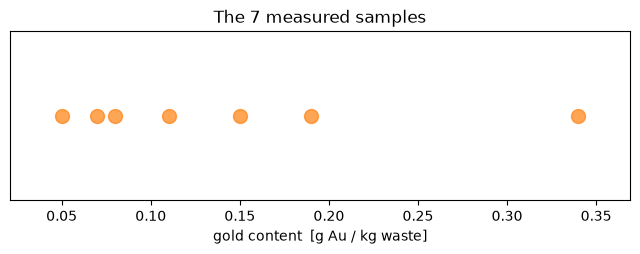

In [2]:
# Gold content [g Au / kg waste] for 7 example samples
gold_content = np.array([0.05, 0.07, 0.08, 0.11, 0.15, 0.19, 0.34])
n = len(gold_content)

plt.figure(figsize=(8, 2.2))
plt.plot(gold_content, np.zeros(n), "o", color="C1", ms=10, alpha=0.7)
plt.yticks([])
plt.xlabel("gold content  [g Au / kg waste]")
plt.title(f"The {n} measured samples")
plt.margins(x=0.1);

## 2. Summarise the sample

We only need two numbers to describe the mean and its small-sample uncertainty:
the **sample mean** content and the **sample standard deviation**. We work
directly with the content values, so the mean we estimate is the **arithmetic
mean** — the quantity that, multiplied by a total mass, gives a total gold flow.

In [3]:
xbar = gold_content.mean()          # arithmetic mean content [g/kg]
s = gold_content.std(ddof=1)        # sample standard deviation (note ddof=1)

print(f"n                     = {n}")
print(f"sample mean   (xbar)  = {xbar:.4f} g/kg")
print(f"sample std    (s)     = {s:.4f} g/kg")

n                     = 7
sample mean   (xbar)  = 0.1414 g/kg
sample std    (s)     = 0.1001 g/kg


## 3. The distribution for the *mean*

We do not know the true mean content; we only have `xbar` from 7 points. Its
uncertainty is described by a **Student-*t* distribution** with `n − 1 = 6`
degrees of freedom, centred on `xbar` with scale `s / √n`:

    mean content  ~  t(df = n − 1),  loc = xbar,  scale = s / √n

The *t* (rather than a normal) is what accounts for the small sample: with only 7
points, `s` is itself uncertain, so the tails are fatter.

Gold content can't be negative, but the *t* has unbounded tails, so a few draws
can fall below zero. We simply **clip** those to zero.

In [4]:
mean_dist = scipy.stats.t(df=n - 1, loc=xbar, scale=s / np.sqrt(n))

# Analytic 95% confidence interval for the mean content:
lo, hi = np.clip(mean_dist.ppf([0.025, 0.975]), 0, None)
print(f"mean content: best estimate {xbar:.3f} g/kg,  95% CI [{lo:.3f}, {hi:.3f}] g/kg")

mean content: best estimate 0.141 g/kg,  95% CI [0.049, 0.234] g/kg


Draw many samples of the mean content and look at its distribution. Notice how
much **narrower** it is than the spread of the 7 raw points (orange ticks): even
7 samples pin down the *mean* far better than they pin down any *individual*
device — but the small-sample *t* keeps that band honestly wide.

100 of 20000 draws fell below zero (heavy t tail) and were clipped


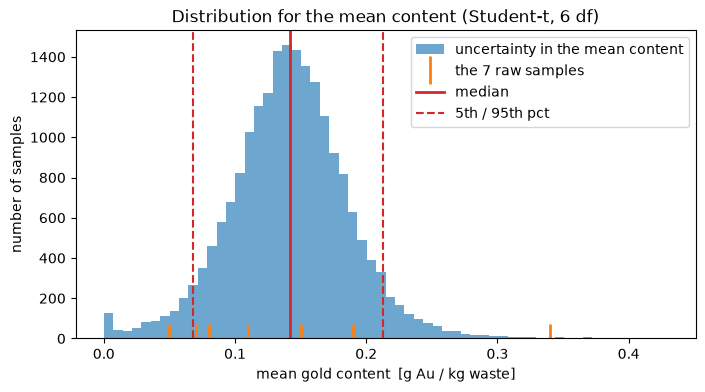

In [5]:
N = 20_000
draws = mean_dist.rvs(N, random_state=rng)
n_clipped = int((draws < 0).sum())
mean_content_samples = np.clip(draws, 0, None)          # content can't be negative
print(f"{n_clipped} of {N} draws fell below zero (heavy t tail) and were clipped")

q5, q50, q95 = np.percentile(mean_content_samples, [5, 50, 95])

plt.figure(figsize=(8, 4))
plt.hist(mean_content_samples, bins=60, color="C0", alpha=0.65,
         label="uncertainty in the mean content")
plt.plot(gold_content, np.zeros(n), "|", color="C1", ms=20, mew=2,
         label="the 7 raw samples")
plt.axvline(q50, color="C3", lw=2, label="median")
plt.axvline(q5, color="C3", ls="--"); plt.axvline(q95, color="C3", ls="--", label="5th / 95th pct")
plt.xlabel("mean gold content  [g Au / kg waste]")
plt.ylabel("number of samples")
plt.title("Distribution for the mean content (Student-t, 6 df)")
plt.legend();

## 4. Propagate to the gold flow

The gold flow is

    gold flow [g/yr]  =  mass flow [kg/yr]  ×  mean gold content [g/kg]

The mass flow comes from the dMFA and has its own uncertainty; here we give it a
nominal value with a modest ±10 % spread. We then run a simple Monte Carlo,
drawing both the mass flow **and** the mean content, to see how the small-sample
uncertainty in the content feeds through.

In [6]:
mass_mean = 20_000e3      # kg of e-waste per year  (= 20,000 tonnes/yr)
mass_cv = 0.10            # 10% spread on the mass flow

mass_samples = np.clip(rng.normal(mass_mean, mass_cv * mass_mean, N), 0, None)

# Two versions, to isolate the effect of the content uncertainty:
#   (a) content fixed at the point estimate  -> only the mass flow is uncertain
#   (b) content drawn from the Student-t      -> mass AND mean-content uncertain
gold_flow_fixed = mass_samples * xbar                  # g/yr
gold_flow_full  = mass_samples * mean_content_samples  # g/yr

# Convert to kg of gold per year for readability:
gold_flow_fixed_kg = gold_flow_fixed / 1000
gold_flow_full_kg  = gold_flow_full / 1000

Compare the two predicted gold-flow distributions. Accounting for the uncertain
mean content (blue) widens the prediction markedly compared with pretending the
content is known exactly (grey).

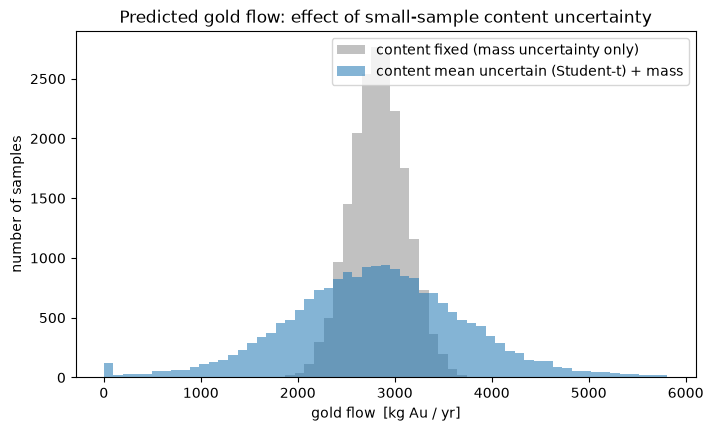

In [7]:
plt.figure(figsize=(8, 4.5))
bins = np.linspace(0, np.percentile(gold_flow_full_kg, 99.5), 60)
plt.hist(gold_flow_fixed_kg, bins=bins, color="0.6", alpha=0.6,
         label="content fixed (mass uncertainty only)")
plt.hist(gold_flow_full_kg, bins=bins, color="C0", alpha=0.55,
         label="content mean uncertain (Student-t) + mass")
plt.xlabel("gold flow  [kg Au / yr]")
plt.ylabel("number of samples")
plt.title("Predicted gold flow: effect of small-sample content uncertainty")
plt.legend();

And the numbers behind the picture — the 5th / 50th / 95th percentiles of the
predicted gold flow under each assumption:

In [8]:
def summary(x_kg):
    p5, p50, p95 = np.percentile(x_kg, [5, 50, 95])
    return {"5th": p5, "median": p50, "95th": p95, "90% band width / median": (p95 - p5) / p50}

table = pd.DataFrame(
    {
        "content fixed": summary(gold_flow_fixed_kg),
        "content uncertain": summary(gold_flow_full_kg),
    }
).T
print("Predicted gold flow  [kg Au / yr]:\n")
print(table.round(2).to_string())

Predicted gold flow  [kg Au / yr]:

                       5th   median     95th  90% band width / median
content fixed      2366.95  2829.47  3297.31                     0.33
content uncertain  1321.38  2815.72  4377.53                     1.09


## Takeaways

- With only 7 samples, the uncertainty in the **mean** content is captured by a
  **Student-*t*** (here 6 df) — wider-tailed than a normal precisely *because*
  the sample is small.
- We model the **arithmetic mean** directly — the right multiplier for a total
  flow — and clip the rare negative draw from the *t*'s unbounded tail.
- That content uncertainty dominates the gold-flow prediction: the 90 % band is
  far wider than the ±10 % mass-flow spread alone. Because the *t* has heavy
  tails (and we clip at zero), we report **percentiles**, not mean ± sd.
- This is the *within-data* uncertainty only. It says nothing about whether these
  7 samples are **representative** of all electronics — that is a separate source
  (see the pedigree / data-quality discussion in Notebook 6), and it would only
  *add* to the band shown here.